(WillmoreOpen)=
# Willmore flow for open surfaces

We test now the capabilities of our solver for open surfaces. In the notebook for [closed surfaces](WillmoreClosed) we have seen that spheres are stable under Willmore flow.

We will exploit this fact since our software can take into account open surfaces. By default, the boundaries are considered as clamped. Let's try with an open sphere

------------------------------------------------------------
The mesh is a  3D mesh
! The mesh is also an hypersurface embedded in  3D !
The number of:
     vertices is:  780
     edges is:  2274
     faces is:  1495
     facets is:  1495
     elements is:  0 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  
Regions of co-dimension  1 :
 N.  1 region(s) called  default
Regions of co-dimension  2 :
 N.  1 region(s) called  bottom
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for the Willmore flow
It computes one step of it given the mesh
The algorithm is described in the article:
Stabilization for the mean curvature is implemented as in the article:
It uses conforming H-1 elements of order  1
Its parameters are
  - clamped_bnd - with value  bottom
  - rhs - with value  ZeroCoefficientFunction
  - sp_curv - with value  ZeroCoefficientFunction
  - domain - with value 

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 11.65it/s]

Simulation concluded successfully
----------


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time  displacement  mean_curv
0   0.00      0.000000   0.570173
1   0.01      0.007176   0.147245
2   0.02      0.003960   0.131542
3   0.03      0.002822   0.122635
4   0.04      0.002495   0.116509
5   0.05      0.002291   0.111438
6   0.06      0.002109   0.107299
7   0.07      0.001941   0.104057
8   0.08      0.001786   0.101630
9   0.09      0.001642   0.099915
10  0.10      0.001510   0.098805


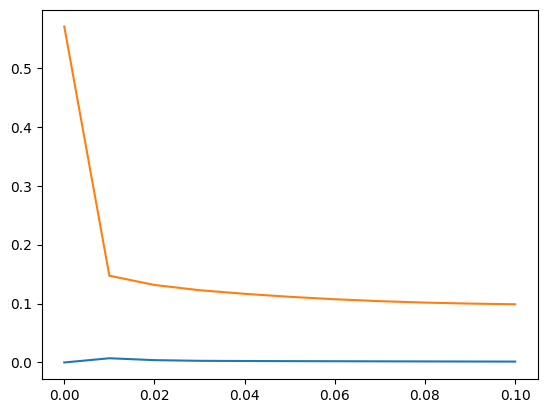

In [1]:
# %%

from cosmos.solvers.willmore import WillmoreSolver
from cosmos.solvers.simulation import MovingSimulation
from cosmos.utils.generate_surface_meshes import generate_half_sphere
from ngsolve import *
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import pandas as pd


mesh, _ = generate_half_sphere(R=1)

n_ex = CF((x,y,z))/Norm(CF((x,y,z)))

'''
Definition of the time parameters
'''
T = 0.1
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T, verbose = 1)

displ_solver = WillmoreSolver(clamped_bnd = 'bottom')

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'open_sphere', n_steps = 10)
displ_solver.ComputeError(folderpath = './willmore_results/', filename = 'open_sphere_errs', ex_sol = [CF((0,0, 0)), -2*n_ex], norm = 'L2')


simulation.run()

displ_solver.draw_solution()


file_path = "./willmore_results/open_sphere_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['displacement'])
plt.plot(df['Time'], df['mean_curv'])
plt.show()


Now let's test an open torus

------------------------------------------------------------
The mesh is a  3D mesh
! The mesh is also an hypersurface embedded in  3D !
The number of:
     vertices is:  754
     edges is:  2198
     faces is:  1444
     facets is:  1444
     elements is:  0 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  membrane
Regions of co-dimension  2 :
 N.  2 region(s) called  default
 N.  4 region(s) called  bottom
Regions of co-dimension  3 :
 N.  4 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for the Willmore flow
It computes one step of it given the mesh
The algorithm is described in the article:
Stabilization for the mean curvature is implemented as in the article:
It uses conforming H-1 elements of order  1
Its parameters are
  - clamped_bnd - with value  bottom
  - rhs - with va

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 11.64it/s]


Simulation concluded successfully
----------


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time  displacement  mean_curv
0   0.00      0.000000   1.702700
1   0.01      0.033695   0.946604
2   0.02      0.021679   0.907429
3   0.03      0.014704   0.821354
4   0.04      0.012028   0.796342
5   0.05      0.009689   0.787960
6   0.06      0.008240   0.789343
7   0.07      0.007266   0.793601
8   0.08      0.006628   0.798315
9   0.09      0.006193   0.802555
10  0.10      0.005879   0.806117


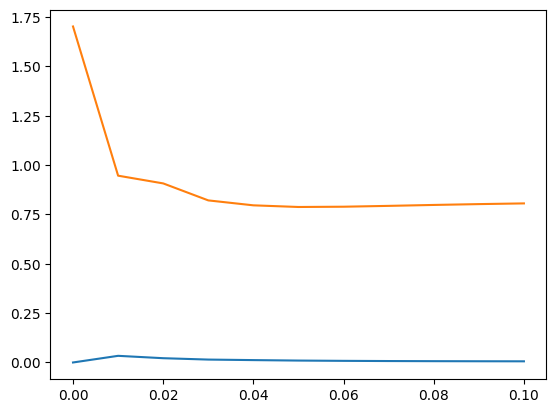

In [2]:
from cosmos.utils.generate_surface_meshes import generate_half_torus

r = 1
R = sqrt(2)

mesh, _ = generate_half_torus(R=R, r=r, maxh = 0.2)

displ_ex = CF((0, 0, 0))

n = CF((x,y,z))/r-R*CF((x,0,z))/r/sqrt(x**2+z**2)
cosv = (sqrt(x**2+z**2)-R)/r
H = 2*(R+2*r*cosv)/(2*r*(R+r*cosv))
mc_exact = -n*H

'''
Definition of the time parameters
'''
T = 0.1
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T, verbose = 1)

displ_solver = WillmoreSolver(clamped_bnd = 'bottom')

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'open_torus', n_steps = 10)
displ_solver.ComputeError(folderpath = './willmore_results/', filename = 'open_torus_errs', ex_sol = [displ_ex, mc_exact], norm = 'L2')


simulation.run()

displ_solver.draw_solution()


file_path = "./willmore_results/open_torus_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['displacement'])
plt.plot(df['Time'], df['mean_curv'])
plt.show()


And finally with an arc

------------------------------------------------------------
The mesh is a  2D mesh
! The mesh is also an hypersurface embedded in  2D !
The number of:
     vertices is:  21
     edges is:  20
     faces is:  0
     facets is:  20
     elements is:  0 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  default
Regions of co-dimension  2 :
 N.  2 region(s) called  boundary
------------------------------------------------------------ 

------------------------------------------------------------
This is a solver for the Willmore flow
It computes one step of it given the mesh
The algorithm is described in the article:
Stabilization for the mean curvature is implemented as in the article:
It uses conforming H-1 elements of order  1
Its parameters are
  - clamped_bnd - with value  boundary
  - rhs - with value  ZeroCoefficientFunction
  - sp_curv - with value  ZeroCoefficientFunction
  - domain - with val

Running Simulation...: 100%|██████████████| 10/10 [00:00<00:00, 310.71it/s]

Simulation concluded successfully
----------


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time  displacement  mean_curv
0   0.00      0.000000   0.521442
1   0.01      0.011893   0.202193
2   0.02      0.006099   0.178586
3   0.03      0.004223   0.167097
4   0.04      0.003563   0.160444
5   0.05      0.003313   0.155292
6   0.06      0.003184   0.150714
7   0.07      0.003093   0.146451
8   0.08      0.003016   0.142422
9   0.09      0.002945   0.138596
10  0.10      0.002878   0.134959


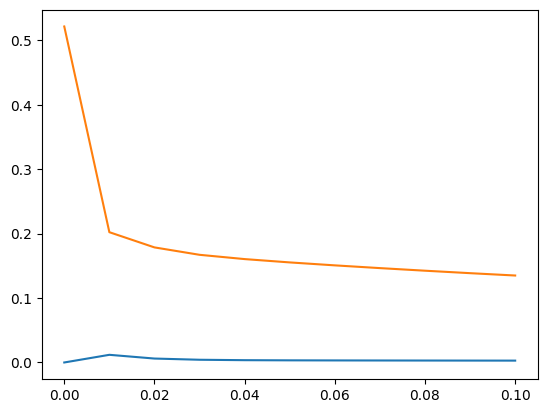

In [3]:
from cosmos.utils.generate_surface_meshes import generate_arc

r = 1
R = sqrt(2)

mesh, _ = generate_arc(N=20)

displ_ex = CF((0, 0))
mc_exact = -CF((x,y))/Norm(CF((x,y)))

'''
Definition of the time parameters
'''
T = 0.1
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T, verbose = 1)

displ_solver = WillmoreSolver(clamped_bnd = 'boundary')

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'open_arc', n_steps = 10)
displ_solver.ComputeError(folderpath = './willmore_results/', filename = 'open_arc_errs', ex_sol = [displ_ex, mc_exact], norm = 'L2')


simulation.run()

displ_solver.draw_solution()


file_path = "./willmore_results/open_arc_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['displacement'])
plt.plot(df['Time'], df['mean_curv'])
plt.show()
